<a href="https://colab.research.google.com/github/updp16/Research_Appendices/blob/main/Model_Development_Chla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Support Vector Regressor**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

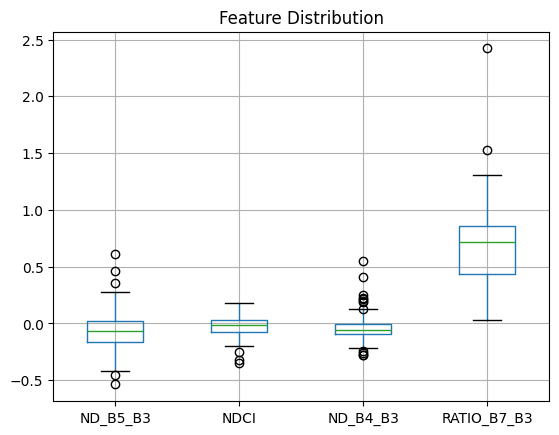

In [ ]:
import matplotlib.pyplot as plt

df[selected_features].boxplot()
plt.title("Feature Distribution")
plt.show()

In [ ]:
df = pd.read_csv(r"https://raw.githubusercontent.com/updp16/research/refs/heads/main/Features_Shell_point.csv")

selected_features = ['RATIO_B5_B4', 'RATIO_B2_B4', 'ND_B5_B12', 'ND_B5_B3',  'ND_B5_B4', 'ND_B3_B4']

X = df[selected_features]
y = df['Actual']

X = df[selected_features]
y = df['Actual']

# Clean data
X = X.replace([np.inf, -np.inf], np.nan)
data = pd.concat([X, y], axis=1).dropna()

X = data[selected_features]
y = data['Actual']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR
svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
svr.fit(X_train_scaled, y_train)

# Predict
y_pred = svr.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# Compare
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

R²: 0.34201837664962376
RMSE: 1.022426887815844
MAE: 0.7857551667258572
   Actual  Predicted
0    3.60   2.711873
1    4.87   3.721894
2    2.20   1.650433
3    1.52   1.710751
4    0.58   2.387849
5    1.64   2.005360
6    1.34   1.722546
7    1.44   2.196868
8    4.52   3.179179
9    1.92   1.795474


     

---





# **Random Forest**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv(r"https://raw.githubusercontent.com/updp16/research/refs/heads/main/Features_Shell_point.csv")

selected_features = ['ND_B5_B3', 'ND_B5_B4', 'ND_B4_B3', 'RATIO_B7_B3']

X = df[selected_features]
y = df['Actual']

X = df[selected_features]
y = df['Actual']

# Clean data
X = X.replace([np.inf, -np.inf], np.nan)
data = pd.concat([X, y], axis=1).dropna()

X = data[selected_features]
y = data['Actual']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R²:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE: " , mean_absolute_error(y_test, y_pred_rf))

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

print(results.head(10))

RF R²: 0.628727081116879
RF RMSE: 0.7680190917145844
MAE:  0.5669857142857139
   Actual  Predicted
0    3.60    4.22340
1    4.87    4.22450
2    2.20    1.54360
3    1.52    1.64670
4    0.58    1.74005
5    1.64    1.96795
6    1.34    1.51600
7    1.44    1.29455
8    4.52    3.89305
9    1.92    1.75620


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Load dataset
df = pd.read_csv(r"https://raw.githubusercontent.com/updp16/research/refs/heads/main/Features_Shell_point.csv")

# 2. Select input features and target
#['ND_B5_B3', 'ND_B5_B4', 'ND_B4_B3', 'RATIO_B7_B3']
selected_features = ['RATIO_B5_B4', 'RATIO_B2_B4', 'ND_B5_B12', 'ND_B5_B3', 'RATIO_B5_B3', 'ND_B5_B4', 'ND_B3_B4']
X = df[selected_features]
y = df['Actual']

# 3. Clean data
X = X.replace([np.inf, -np.inf], np.nan)
data = pd.concat([X, y], axis=1).dropna()

X = data[selected_features]
y = data['Actual']

# 4. Split data into training and testing sets
X_train, X_test1, y_train, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Define Random Forest model
rf = RandomForestRegressor(random_state=42)

# 6. Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# 7. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# 8. Train model using GridSearchCV
grid_search.fit(X_train, y_train)

# 9. Get the best model
best_rf = grid_search.best_estimator_

# 10. Predict on test data
y_pred1 = best_rf.predict(X_test1)

# 11. Evaluate model performance
print("----- RANDOM FOREST GRID SEARCH RESULTS -----")
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")
print(f"Test R² Score: {r2_score(y_test1, y_pred1):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred1)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test1, y_pred1):.4f}")

# 12. Show actual vs predicted values
results = pd.DataFrame({
    'Actual': y_test1.values,
    'Predicted': y_pred1
})

print("\nFirst 10 predictions:")
print(results.head(10))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
----- RANDOM FOREST GRID SEARCH RESULTS -----
Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² Score: 0.3051
Test R² Score: 0.6076
Test RMSE: 0.7896
Test MAE: 0.5716

First 10 predictions:
   Actual  Predicted
0    3.60   4.127878
1    4.87   4.227160
2    2.20   1.728368
3    1.52   1.765030
4    0.58   1.673572
5    1.64   2.006892
6    1.34   1.736779
7    1.44   1.509559
8    4.52   3.869743
9    1.92   1.802100


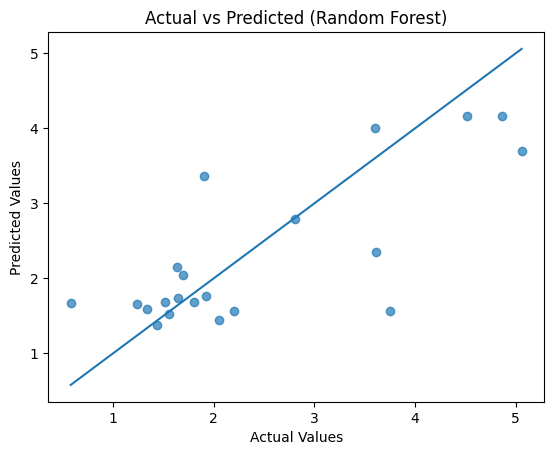

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test1, y_pred1, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")

# Ideal line
min_val = min(y_test1.min(), y_pred1.min())
max_val = max(y_test1.max(), y_pred1.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()



---



**Residual plot**

👉 Shows error distribution

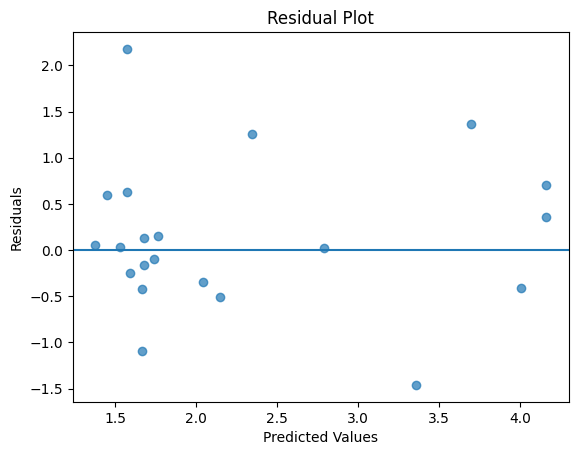

In [ ]:
residuals = y_test1 - y_pred1

plt.figure()
plt.scatter(y_pred1, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Points are randomly scattered around zero with no systematic pattern ==> the model does not exhibit systematic bias.



---



---





**Feature importance**

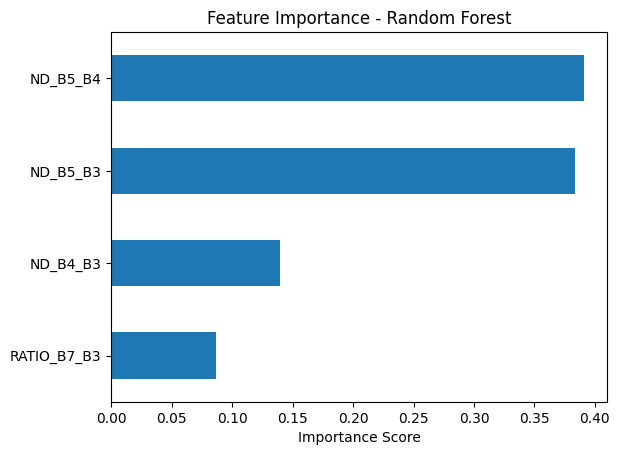

In [ ]:
import pandas as pd

importance = best_rf.feature_importances_

feature_importance = pd.Series(importance, index=selected_features)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# **ANN**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/updp16/research/refs/heads/main/Chla-data_set.csv")

# 2. Select all features and target
X = df.drop(columns=['Actual'])
y = df['Actual']

# 3. Clean data
X = X.replace([np.inf, -np.inf], np.nan)
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=['Actual'])
y = data['Actual']

# 4. Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 5. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 6. Build smaller ANN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1)
])

# 7. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 8. Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# 9. Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

# 10. Predict
y_pred = model.predict(X_test_scaled).flatten()

# 11. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("----- ANN RESULTS -----")
print(f"Test R² Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nFirst 10 predictions:")
print(results.head(10))

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 39.8719 - mae: 4.6686 - val_loss: 59.1350 - val_mae: 5.0932
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 34.0379 - mae: 4.2050 - val_loss: 50.4457 - val_mae: 4.4621
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.7332 - mae: 3.7861 - val_loss: 44.1015 - val_mae: 3.9886
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.2048 - mae: 3.7465 - val_loss: 41.6737 - val_mae: 3.8941
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.8884 - mae: 3.7109 - val_loss: 39.8343 - val_mae: 3.8365
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.6029 - mae: 3.5747 - val_loss: 38.4397 - val_mae: 3.7110
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.8079 - mae: 3.5630 - val_loss: 36.9044 - val_mae: 3.5908
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22.5467 - mae: 3.3345 - val_loss: 35.8706 - val_mae: 3.5633
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s